In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sys import stdout
from itertools import product as iterproduct
from scipy.signal import savgol_filter

from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_predict


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import astartes as at


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


In [2]:
X_raw      = pd.read_csv('../CSV/rawX.csv', header=None).values
y_carbon   = pd.read_csv('../CSV/rawyCarbon.csv', header=None).values.ravel()
y_nitrogen = pd.read_csv('../CSV/rawyNitrogen.csv', header=None).values.ravel()

X_raw.shape

(144, 256)

In [3]:
def filter_reflectance_data(X, y):
    """
    Remove amostras onde os valores de refletância estão fora do intervalo [0, 1]

    Parameters:
    X : array-like, shape (n_samples, n_features)
        Dados espectrais de refletância
    y : array-like, shape (n_samples,)
        Valores alvo correspondentes

    Returns:
    X_filtered : array, shape (n_filtered_samples, n_features)
        Dados X filtrados
    y_filtered : array, shape (n_filtered_samples,)
        Dados y filtrados
    removed_indices : array
        Índices das amostras removidas
    """

    # Verificar se há valores fora do intervalo [0, 1]
    invalid_mask = np.any((X < 0) | (X > 1), axis=1)

    # Obter índices das amostras inválidas
    removed_indices = np.where(invalid_mask)[0]

    # Manter apenas amostras válidas
    valid_mask = ~invalid_mask
    X_filtered = X[valid_mask]
    y_filtered = y[valid_mask]

    # Relatório
    n_total = X.shape[0]
    n_removed = len(removed_indices)
    n_remaining = X_filtered.shape[0]

    print(f"ANÁLISE DE DADOS ESPECTRAIS")
    print(f"Total de amostras: {n_total}")
    print(f"Amostras removidas: {n_removed}")
    print(f"Amostras restantes: {n_remaining}")
    print(f"Percentual removido: {n_removed / n_total * 100:.2f}%")

    if n_removed > 0:
        print(f"Índices das amostras removidas: {removed_indices}")

        # Analisar a natureza dos problemas
        negative_count = np.sum(np.any(X < 0, axis=1))
        above_one_count = np.sum(np.any(X > 1, axis=1))
        print(f"Amostras com valores negativos: {negative_count}")
        print(f"Amostras com valores > 1: {above_one_count}")

        # Estatísticas dos valores problemáticos
        if negative_count > 0:
            min_val = np.min(X)
            print(f"Valor mínimo encontrado: {min_val:.6f}")
        if above_one_count > 0:
            max_val = np.max(X)
            print(f"Valor máximo encontrado: {max_val:.6f}")

    return X_filtered, y_filtered, removed_indices

In [4]:
X_filteredC, y_filteredC, removed_indicesC = filter_reflectance_data(X_raw, y_carbon)

ANÁLISE DE DADOS ESPECTRAIS
Total de amostras: 144
Amostras removidas: 4
Amostras restantes: 140
Percentual removido: 2.78%
Índices das amostras removidas: [ 19 113 115 121]
Amostras com valores negativos: 3
Amostras com valores > 1: 1
Valor mínimo encontrado: -0.023029
Valor máximo encontrado: 1.134630


In [5]:
X_filteredN, y_filteredN, removed_indicesN = filter_reflectance_data(X_raw, y_nitrogen)

ANÁLISE DE DADOS ESPECTRAIS
Total de amostras: 144
Amostras removidas: 4
Amostras restantes: 140
Percentual removido: 2.78%
Índices das amostras removidas: [ 19 113 115 121]
Amostras com valores negativos: 3
Amostras com valores > 1: 1
Valor mínimo encontrado: -0.023029
Valor máximo encontrado: 1.134630


In [6]:
def apply_sg(X, window, polyorder, deriv):
    return savgol_filter(X, window_length=window, polyorder=polyorder, deriv=deriv, axis=1)


def sg_grid_search(X, y, windows=None, polyorders=None, derivs=None, cv=10, label=''):
    if windows    is None: windows    = [5, 7, 9, 11, 13, 15, 17, 21, 31, 41]
    if polyorders is None: polyorders = [1, 2, 3]
    if derivs     is None: derivs     = [0, 1, 2]

    combos = [(w, p, d) for w, p, d in iterproduct(windows, polyorders, derivs) if p < w]
    print(f'[{label}] {len(combos)} combinações SG...')

    best_rmse, best_params, results = np.inf, None, []
    for idx, (w, p, d) in enumerate(combos):
        try:
            X_sg = apply_sg(X, w, p, d)
            X_sc = StandardScaler().fit_transform(X_sg)
            best_cv, best_nc = np.inf, 1
            for nc in range(1, min(20, X.shape[0] // cv)):
                cv_rmse = -cross_val_score(
                    PLSRegression(n_components=nc), X_sc, y,
                    cv=cv, scoring='neg_root_mean_squared_error').mean()
                if cv_rmse < best_cv:
                    best_cv, best_nc = cv_rmse, nc
            results.append({'window': w, 'polyorder': p, 'deriv': d,
                            'n_comp': best_nc, 'cv_rmse': best_cv})
            if best_cv < best_rmse:
                best_rmse = best_cv
                best_params = {'window': w, 'polyorder': p, 'deriv': d, 'n_comp': best_nc}
        except Exception:
            continue
        stdout.write(f'\r  {100*(idx+1)/len(combos):.0f}% | melhor RMSE={best_rmse:.5f}')
        stdout.flush()
    print()
    df = pd.DataFrame(results).sort_values('cv_rmse').reset_index(drop=True)
    print(f'  → window={best_params["window"]}, polyorder={best_params["polyorder"]}, '
          f'deriv={best_params["deriv"]}, n_comp={best_params["n_comp"]}')
    return best_params, df


print('=== SG Grid Search — Carbono ===')
sg_C, df_sg_C = sg_grid_search(X_filteredC, y_filteredC, label='C')
print('\n=== SG Grid Search — Nitrogênio ===')
sg_N, df_sg_N = sg_grid_search(X_filteredN, y_filteredN, label='N')

=== SG Grid Search — Carbono ===
[C] 90 combinações SG...
  100% | melhor RMSE=0.79000
  → window=17, polyorder=2, deriv=1, n_comp=11

=== SG Grid Search — Nitrogênio ===
[N] 90 combinações SG...
  100% | melhor RMSE=0.07459
  → window=15, polyorder=2, deriv=1, n_comp=11


Top-10 SG — Carbono:
 window  polyorder  deriv  n_comp  cv_rmse
     17          2      1      11 0.789999
     11          2      1      10 0.790309
     13          2      1      10 0.790992
     15          2      1      11 0.791149
     15          1      1      11 0.791562
     21          2      1      12 0.793969
     21          1      1      11 0.795061
     17          1      1      11 0.796127
     31          3      1      11 0.796981
     41          3      1      11 0.801115

Top-10 SG — Nitrogênio:
 window  polyorder  deriv  n_comp  cv_rmse
     15          2      1      11 0.074594
     31          3      1      11 0.074781
     13          2      1      11 0.074786
     21          3      1      11 0.074923
     13          1      1      11 0.074926
     11          2      1      10 0.074963
     15          1      1      11 0.075070
     17          3      1      11 0.075402
     11          1      1      11 0.075681
     17          1      1      11 0.075718


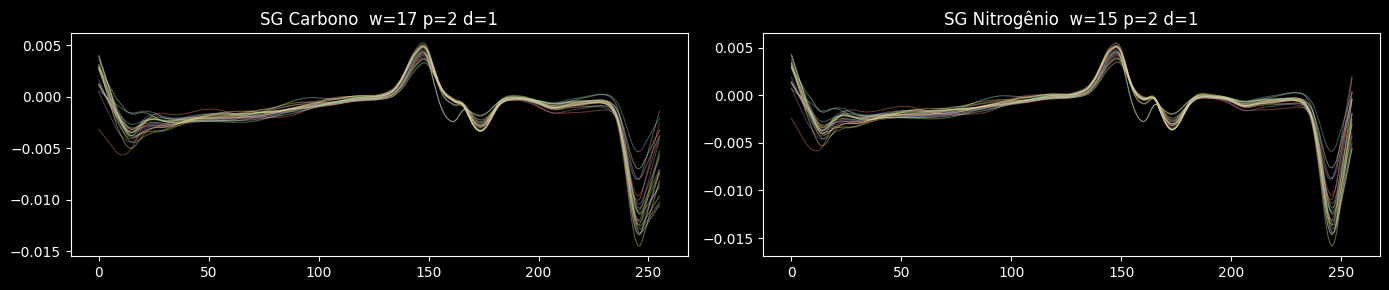

In [7]:
XC_sg = apply_sg(X_filteredC, sg_C['window'], sg_C['polyorder'], sg_C['deriv'])
XN_sg = apply_sg(X_filteredN, sg_N['window'], sg_N['polyorder'], sg_N['deriv'])

print('Top-10 SG — Carbono:')
print(df_sg_C.head(10).to_string(index=False))
print('\nTop-10 SG — Nitrogênio:')
print(df_sg_N.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
for i in range(min(20, XC_sg.shape[0])):
    axes[0].plot(XC_sg[i], alpha=0.4, lw=0.8)
axes[0].set_title(f'SG Carbono  w={sg_C["window"]} p={sg_C["polyorder"]} d={sg_C["deriv"]}')
for i in range(min(20, XN_sg.shape[0])):
    axes[1].plot(XN_sg[i], alpha=0.4, lw=0.8)
axes[1].set_title(f'SG Nitrogênio  w={sg_N["window"]} p={sg_N["polyorder"]} d={sg_N["deriv"]}')
plt.tight_layout(); plt.show()

In [8]:
def pls_data_optimization(X, y, max_components=40, plot_components=True):
    mse_list = []
    max_comp = min(max_components, X.shape[0] - 1, X.shape[1])
    component = np.arange(1, max_comp + 1)
    for i in component:
        pls = PLSRegression(n_components=i)
        pls.fit(X, y)
        mse_list.append(mean_squared_error(y, pls.predict(X)))
        stdout.write(f'\r  {100*i/max_comp:.0f}%')
        stdout.flush()
    stdout.write('\n')
    msemin = int(np.argmin(mse_list))
    n_opt = msemin + 1
    print(f'  Componentes ótimos: {n_opt}')
    if plot_components:
        plt.figure(figsize=(8, 3))
        plt.plot(component, mse_list, '-v', markersize=4)
        plt.plot(n_opt, mse_list[msemin], 'rP', ms=10, label=f'ótimo={n_opt}')
        plt.xlabel('N componentes PLS'); plt.ylabel('MSE'); plt.legend()
        plt.tight_layout(); plt.show()
    return n_opt


def pls_prediction2(X_calib, y_calib, X_valid, y_valid, components, plot_components=True):
    pls = PLSRegression(n_components=components)
    pls.fit(X_calib, y_calib)
    y_pred = pls.predict(X_valid)
    r2   = r2_score(y_valid, y_pred)
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    print(f'  R²={r2:.3f}  RMSE={rmse:.4f}')
    if plot_components:
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.scatter(y_valid, y_pred, s=20, alpha=0.7, edgecolors='k', lw=0.3)
        lim = [min(y_valid.min(), float(y_pred.min())) * 0.95,
               max(y_valid.max(), float(y_pred.max())) * 1.05]
        ax.plot(lim, lim, 'r--')
        ax.set_xlabel('Medido'); ax.set_ylabel('Predito')
        ax.set_title(f'PLS ({components} comp.)  R²={r2:.3f}')
        plt.tight_layout(); plt.show()
    return y_valid, y_pred, pls


def nipals_outlier_removal(X, y, n_components, threshold_std=2.5, label=''):
    print(f'\n── NIPALS — {label} ──')
    print('Otimizando componentes PLS...')
    n_opt = pls_data_optimization(X, y, plot_components=True)
    print(f'\nPLS ({n_opt} comp.) no dataset completo:')
    y_true, y_pred, _ = pls_prediction2(X, y, X, y, components=n_opt, plot_components=True)
    pred_error  = np.abs(y_true - np.ravel(y_pred))
    error_std   = pred_error.std()
    threshold   = threshold_std * error_std
    outlier_mask = pred_error >= threshold
    ind_outliers = np.where(outlier_mask)[0]
    print(f'  Std erro={error_std:.5f} | Limiar={threshold:.5f} | Outliers={len(ind_outliers)}')
    print(f'  Índices: {ind_outliers.tolist()}')
    plt.figure(figsize=(12, 3))
    plt.plot(pred_error, color='orange', label=label)
    plt.plot(ind_outliers, pred_error[outlier_mask], 'ro', label='Outliers')
    plt.axhline(threshold, color='k', ls='--', lw=0.8, label=f'{threshold_std}×std')
    plt.xlabel('Amostra'); plt.ylabel('Erro absoluto')
    plt.title(f'NIPALS — {label}'); plt.legend(); plt.tight_layout(); plt.show()
    X_clean = np.delete(X, ind_outliers, axis=0)
    y_clean = np.delete(y, ind_outliers, axis=0)
    print(f'  {X.shape[0]} → {X_clean.shape[0]} amostras')
    print('PLS no dataset limpo:')
    pls_prediction2(X_clean, y_clean, X_clean, y_clean,
                    components=min(n_opt, X_clean.shape[0] - 1), plot_components=True)
    return X_clean, y_clean, ind_outliers


print('Funções NIPALS definidas.')

Funções NIPALS definidas.



── NIPALS — Carbono ──
Otimizando componentes PLS...
  100%
  Componentes ótimos: 40


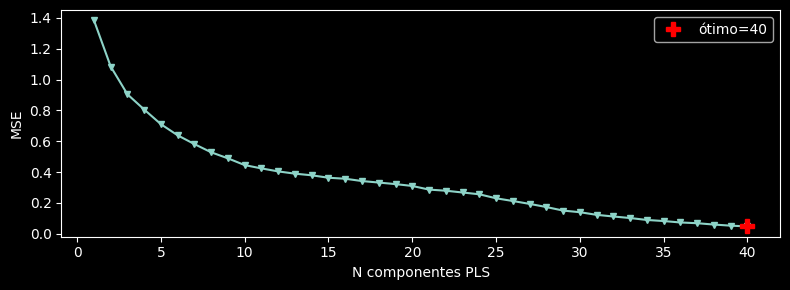


PLS (40 comp.) no dataset completo:
  R²=0.979  RMSE=0.2168


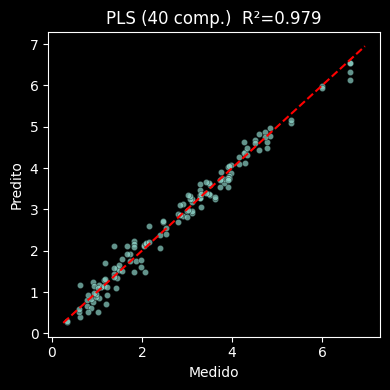

  Std erro=0.13735 | Limiar=0.34338 | Outliers=15
  Índices: [0, 16, 17, 21, 27, 44, 99, 111, 114, 116, 117, 125, 127, 134, 136]


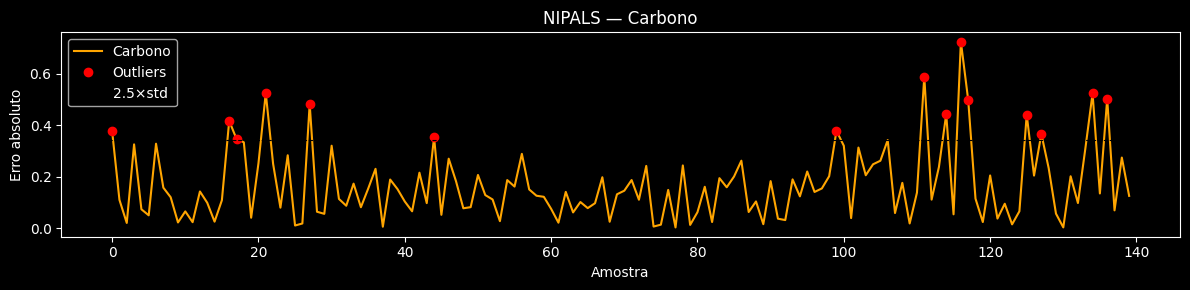

  140 → 125 amostras
PLS no dataset limpo:
  R²=0.994  RMSE=0.1157


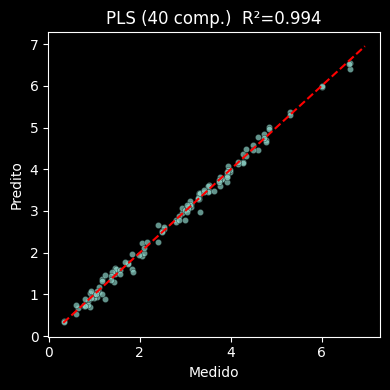

In [9]:
XC_clean, YC_clean, _ = nipals_outlier_removal(
    XC_sg, y_filteredC, sg_C['n_comp'], label='Carbono')



── NIPALS — Nitrogênio ──
Otimizando componentes PLS...
  100%
  Componentes ótimos: 40


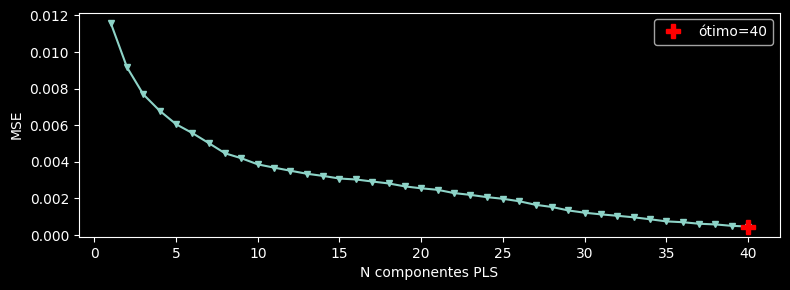


PLS (40 comp.) no dataset completo:
  R²=0.974  RMSE=0.0215


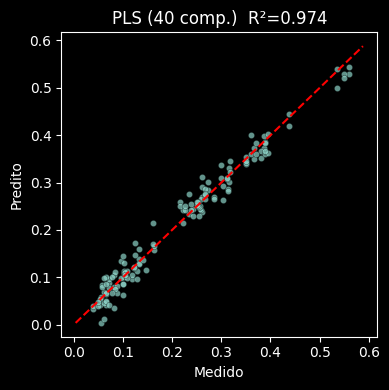

  Std erro=0.01338 | Limiar=0.03346 | Outliers=18
  Índices: [1, 8, 17, 29, 62, 67, 71, 80, 85, 86, 113, 116, 117, 120, 125, 133, 138, 139]


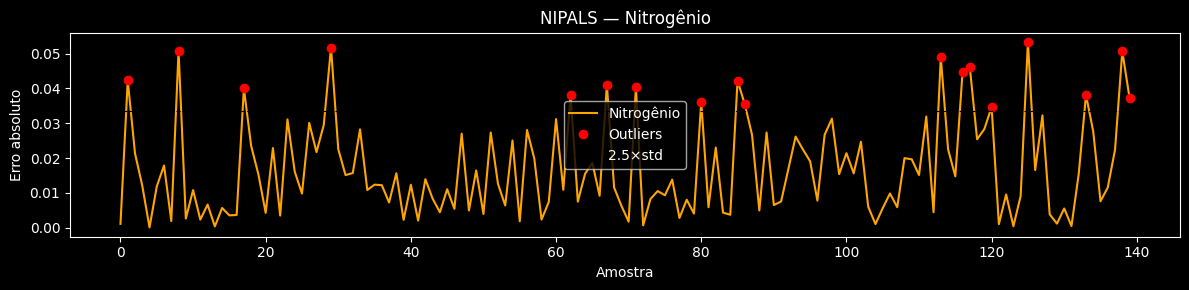

  140 → 122 amostras
PLS no dataset limpo:
  R²=0.995  RMSE=0.0099


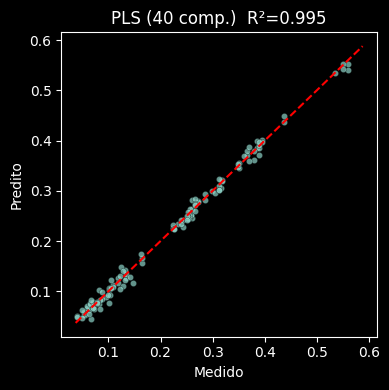

In [10]:
XN_clean, YN_clean, _ = nipals_outlier_removal(
    XN_sg, y_filteredN, sg_N['n_comp'], label='Nitrogênio')

In [11]:
print(f'\nPós pré-processamento — C: {XC_clean.shape} | N: {XN_clean.shape}')


Pós pré-processamento — C: (125, 256) | N: (122, 256)


In [12]:
X_trainC, X_testC, y_trainC, y_testC = at.train_test_split(XC_clean, YC_clean, test_size=0.3)

X_trainN, X_testN, y_trainN, y_testN = at.train_test_split(XN_clean, YN_clean, test_size=0.3)

In [28]:
def avaliarPLS(X_train, y_train, X_test, y_test, max_components=40):

    X_train = X_train
    X_test = X_test
    y_train = y_train
    y_test = y_test

    cv = KFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    rmsecv = []

    print("Otimizando número de componentes...")

    for n_comp in range(1, min(max_components, X_train.shape[1]) + 1):

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('pls', PLSRegression(n_components=n_comp))
        ])

        mse_scores = cross_val_score(
            pipe,
            X_train,
            y_train,
            cv=cv,
            scoring='neg_mean_squared_error',
            n_jobs=-1
        )

        rmse = np.sqrt(-mse_scores.mean())
        rmsecv.append(rmse)

    best_n = np.argmin(rmsecv) + 1

    print(f"\nMelhor número de componentes: {best_n}")
    print(f"RMSECV: {rmsecv[best_n-1]:.5f}")

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('pls', PLSRegression(n_components=best_n))
    ])

    model.fit(X_train, y_train)

    y_test_pred = model.predict(X_test).ravel()

    test_r2 = r2_score(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rpd = np.std(y_test) / test_rmse

    df_test = pd.DataFrame({
        "Métrica": ["R²", "RMSE", "MAE", "RPD"],
        "Valor": [test_r2, test_rmse, test_mae, test_rpd]
    })

    print("\n===== TESTE =====")
    print(df_test)



    y_train_pred = model.predict(X_train).ravel()

    train_r2 = r2_score(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rpd = np.std(y_train) / train_rmse

    df_train = pd.DataFrame({
        "Métrica": ["R²", "RMSE", "MAE", "RPD"],
        "Valor": [train_r2, train_rmse, train_mae, train_rpd]
    })

    print("\n===== TREINO =====")
    print(df_train)

    return model, df_test, df_train

In [29]:
def avaliarSVR(X_train, y_train, X_test, y_test):

    X_train = X_train
    X_test = X_test
    y_train = y_train
    y_test = y_test

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ])

    param_grid = [
        {
            'svr__kernel': ['linear'],
            'svr__C': [0.1, 1, 10, 100]
        },
        {
            'svr__kernel': ['rbf'],
            'svr__C': [0.1, 1, 10, 100, 1000],
            'svr__gamma': ['scale', 1, 0.1, 0.01, 0.001],
            'svr__epsilon': [0.001, 0.01, 0.1]
        }
    ]

    cv = KFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    model = GridSearchCV(
        pipe,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=cv,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    print("\n===== MELHOR MODELO SVR =====")
    print(model.best_params_)

    y_cv = cross_val_predict(
        model.best_estimator_,
        X_train,
        y_train,
        cv=cv,
        n_jobs=-1
    )

    r2cv = r2_score(y_train, y_cv)
    rmsecv = np.sqrt(mean_squared_error(y_train, y_cv))

    y_test_pred = model.predict(X_test)

    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae_test = mean_absolute_error(y_test, y_test_pred)
    rpd_test = np.std(y_test) / rmse_test

    y_train_pred = model.predict(X_train)

    r2_train = r2_score(y_train, y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    mae_train = mean_absolute_error(y_train, y_train_pred)
    rpd_train = np.std(y_train) / rmse_train

    resultados = pd.DataFrame({
        'Conjunto': ['Treino', 'Teste', 'CV'],
        'R²': [r2_train, r2_test, r2cv],
        'RMSE': [rmse_train, rmse_test, rmsecv],
        'MAE': [mae_train, mae_test, np.nan],
        'RPD': [rpd_train, rpd_test, np.nan]
    })

    print(resultados)

    return model, resultados

In [30]:
def avaliarRF(X_train, y_train, X_test, y_test):

    X_train = X_train
    X_test = X_test
    y_train = y_train
    y_test = y_test

    param_grid = {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }

    cv = KFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    model = GridSearchCV(
        RandomForestRegressor(random_state=42),
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=cv,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    print("\n===== MELHOR RANDOM FOREST =====")
    print(model.best_params_)


    y_cv = cross_val_predict(
        model.best_estimator_,
        X_train,
        y_train,
        cv=cv,
        n_jobs=-1
    )

    r2cv = r2_score(y_train, y_cv)
    rmsecv = np.sqrt(mean_squared_error(y_train, y_cv))

    y_test_pred = model.predict(X_test)

    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae_test = mean_absolute_error(y_test, y_test_pred)
    rpd_test = np.std(y_test) / rmse_test

    y_train_pred = model.predict(X_train)

    r2_train = r2_score(y_train, y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    mae_train = mean_absolute_error(y_train, y_train_pred)
    rpd_train = np.std(y_train) / rmse_train

    resultados = pd.DataFrame({
        'Conjunto': ['Treino', 'Teste', 'CV'],
        'R²': [r2_train, r2_test, r2cv],
        'RMSE': [rmse_train, rmse_test, rmsecv],
        'MAE': [mae_train, mae_test, np.nan],
        'RPD': [rpd_train, rpd_test, np.nan]
    })

    print(resultados)

    return model, resultados

In [16]:
class CVAE(nn.Module):
    def __init__(self, input_dim, latent_dim, encoder_dims, decoder_dims):
        super().__init__()
        enc, in_d = [], input_dim + 1
        for out_d in encoder_dims:
            enc += [nn.Linear(in_d, out_d), nn.ReLU()]; in_d = out_d
        self.encoder   = nn.Sequential(*enc)
        self.fc_mu     = nn.Linear(in_d, latent_dim)
        self.fc_logvar = nn.Linear(in_d, latent_dim)
        dec, in_d = [], latent_dim + 1
        for out_d in decoder_dims:
            dec += [nn.Linear(in_d, out_d), nn.ReLU()]; in_d = out_d
        dec.append(nn.Linear(in_d, input_dim))
        self.decoder = nn.Sequential(*dec)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)

    def forward(self, x, y):
        y = y.unsqueeze(1)
        h = self.encoder(torch.cat([x, y], dim=1))
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(torch.cat([z, y], dim=1)), mu, logvar

    def generate(self, y_scaled):
        self.eval()
        with torch.no_grad():
            y_t = torch.FloatTensor(y_scaled).to(DEVICE).unsqueeze(1)
            z   = torch.randn(len(y_scaled), self.fc_mu.out_features).to(DEVICE)
            return self.decoder(torch.cat([z, y_t], dim=1)).cpu().numpy()


CVAE_CONFIGS = {
    'CVAE_1': dict(latent_dim=8,  encoder_dims=[150, 100],              decoder_dims=[100, 150]),
    'CVAE_2': dict(latent_dim=16, encoder_dims=[200, 150, 64],          decoder_dims=[64, 150, 200]),
    'CVAE_3': dict(latent_dim=8,  encoder_dims=[200, 150, 64, 32, 16],  decoder_dims=[16, 32, 64, 150, 200]),
}


def cvae_loss(x_recon, x, mu, logvar, kl_weight=0.5):
    return nn.MSELoss()(x_recon, x) + kl_weight * (-0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()))


def train_cvae(model, X_train, y_train, epochs=300, batch_size=32, lr=1e-3):
    sx = StandardScaler(); sy = StandardScaler()
    X_sc = sx.fit_transform(X_train)
    y_sc = sy.fit_transform(y_train.reshape(-1, 1)).ravel()
    loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_sc), torch.FloatTensor(y_sc)),
        batch_size=min(batch_size, len(X_sc)), shuffle=True)
    model.to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=lr)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.1, patience=5)
    history = []
    model.train()
    for epoch in range(epochs):
        total = 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            x_recon, mu, logvar = model(xb, yb)
            loss = cvae_loss(x_recon, xb, mu, logvar)
            loss.backward(); opt.step()
            total += loss.item()
        avg = total / len(loader)
        sched.step(avg); history.append(avg)
        if (epoch + 1) % 100 == 0:
            print(f'    Época {epoch+1}/{epochs} — Loss={avg:.6f}')
    return model, sx, sy, history


def compare_cvaes(X_gtr, y_gtr, input_dim, label):

    results = {}

    for name, cfg in CVAE_CONFIGS.items():

        print(f'\nTreinando {name} - {label}')

        model = CVAE(
            input_dim,
            cfg['latent_dim'],
            cfg['encoder_dims'],
            cfg['decoder_dims']
        )

        model, sx, sy, hist = train_cvae(
            model,
            X_gtr,
            y_gtr
        )

        results[name] = {
            'model': model,
            'sx': sx,
            'sy': sy,
            'hist': hist
        }

    plt.figure(figsize=(8,4))

    for name, res in results.items():
        plt.plot(res['hist'], label=name)

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'CVAE - {label}')
    plt.show()

    return results


print('CVAE definido.')

CVAE definido.



Treinando CVAE_1 - Carbono
    Época 100/300 — Loss=0.535545
    Época 200/300 — Loss=0.519922
    Época 300/300 — Loss=0.561652

Treinando CVAE_2 - Carbono
    Época 100/300 — Loss=0.451829
    Época 200/300 — Loss=0.454320
    Época 300/300 — Loss=0.467093

Treinando CVAE_3 - Carbono
    Época 100/300 — Loss=0.611754
    Época 200/300 — Loss=0.610022
    Época 300/300 — Loss=0.611215


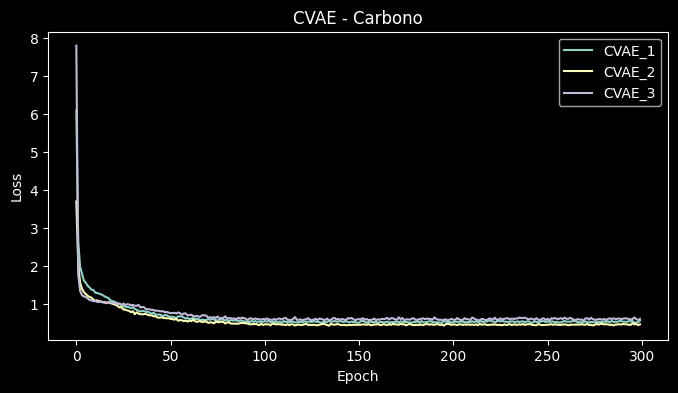


Treinando CVAE_1 - Nitrogênio
    Época 100/300 — Loss=0.592139
    Época 200/300 — Loss=0.574974
    Época 300/300 — Loss=0.579362

Treinando CVAE_2 - Nitrogênio
    Época 100/300 — Loss=0.564738
    Época 200/300 — Loss=0.553543
    Época 300/300 — Loss=0.577190

Treinando CVAE_3 - Nitrogênio
    Época 100/300 — Loss=0.781482
    Época 200/300 — Loss=0.753300
    Época 300/300 — Loss=0.746170


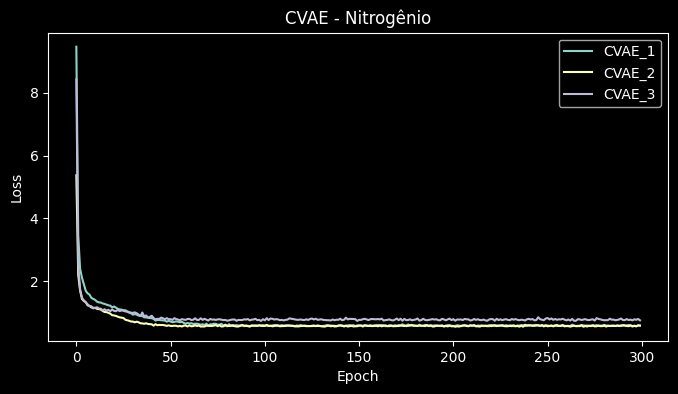

In [17]:
cvae_res_C = compare_cvaes(
    X_trainC,
    y_trainC,
    X_trainC.shape[1],
    'Carbono'
)

cvae_res_N = compare_cvaes(
    X_trainN,
    y_trainN,
    X_trainN.shape[1],
    'Nitrogênio'
)

In [18]:
best_cvae_C = 'CVAE_2'
best_cvae_N = 'CVAE_1'

In [19]:
AUG_PERCENTS = [0.50, 1.00, 1.50, 2.00, 2.50]

def build_augmented(cvae_res, best_name, X_tr, y_tr, aug_percents, seed=SEED):
    """
    Gera datasets aumentados. aug_percents: lista de frações do treino real.
    Ex: 0.5 = +50% do n_treino, 1.0 = +100%, 2.0 = +200%.
    Valores y sintéticos: reamostrados da distribuição real + ruído gaussiano 5% std.
    Retorna dict com chave no formato '+50%', '+100%' etc.
    """
    rng  = np.random.default_rng(seed)
    best = cvae_res[best_name]
    aug  = {}
    n_real = len(X_tr)
    for pct in aug_percents:
        n_syn  = int(np.round(n_real * pct))
        label  = f'+{int(pct*100)}%'
        base_y = rng.choice(y_tr, size=n_syn, replace=True)
        noise  = rng.normal(0, np.std(y_tr) * 0.05, n_syn)
        y_syn  = np.clip(base_y + noise, y_tr.min(), y_tr.max())
        y_sc   = best['sy'].transform(y_syn.reshape(-1, 1)).ravel()
        X_syn  = best['sx'].inverse_transform(best['model'].generate(y_sc))
        X_aug  = np.vstack([X_tr, X_syn])
        y_aug  = np.concatenate([y_tr, y_syn])
        aug[label] = (X_aug, y_aug)
        print(f'  {label} ({n_syn} sintéticos): treino total={X_aug.shape[0]}')
    return aug


aug_C = build_augmented(
    cvae_res_C,
    best_cvae_C,
    X_trainC,
    y_trainC,
    AUG_PERCENTS
)

aug_N = build_augmented(
    cvae_res_N,
    best_cvae_N,
    X_trainN,
    y_trainN,
    AUG_PERCENTS
)

  +50% (44 sintéticos): treino total=133
  +100% (89 sintéticos): treino total=178
  +150% (134 sintéticos): treino total=223
  +200% (178 sintéticos): treino total=267
  +250% (222 sintéticos): treino total=311
  +50% (44 sintéticos): treino total=131
  +100% (87 sintéticos): treino total=174
  +150% (130 sintéticos): treino total=217
  +200% (174 sintéticos): treino total=261
  +250% (218 sintéticos): treino total=305


In [20]:
for nome, (X_aug, y_aug) in aug_C.items():
    print(nome)
    print(X_aug.shape)
    print(y_aug.shape)
    print()

+50%
(133, 256)
(133,)

+100%
(178, 256)
(178,)

+150%
(223, 256)
(223,)

+200%
(267, 256)
(267,)

+250%
(311, 256)
(311,)



In [21]:
for nome, (X_aug, y_aug) in aug_N.items():
    print(nome)
    print(X_aug.shape)
    print(y_aug.shape)
    print()

+50%
(131, 256)
(131,)

+100%
(174, 256)
(174,)

+150%
(217, 256)
(217,)

+200%
(261, 256)
(261,)

+250%
(305, 256)
(305,)



# Avaliação Carbono

## Avaliação PLS ##

In [34]:
resultados_aug = {}

for nivel, (X_aug, y_aug) in aug_C.items():

    print(f"\n========== {nivel} ==========")

    modelo, res_test, res_treino  = avaliarPLS(
        X_aug,
        y_aug,
        X_testC,
        y_testC
    )

    resultados_aug[nivel] = {
        'teste': res_test,
        'treino': res_treino
    }


========== +50% ==========
Otimizando número de componentes...

Melhor número de componentes: 12
RMSECV: 0.76084

===== TESTE =====
  Métrica     Valor
0      R²  0.692380
1    RMSE  0.886967
2     MAE  0.726928
3     RPD  1.802987

===== TREINO =====
  Métrica     Valor
0      R²  0.854833
1    RMSE  0.517501
2     MAE  0.399978
3     RPD  2.624619

========== +100% ==========
Otimizando número de componentes...

Melhor número de componentes: 11
RMSECV: 0.70970

===== TESTE =====
  Métrica     Valor
0      R²  0.675634
1    RMSE  0.910789
2     MAE  0.745929
3     RPD  1.755830

===== TREINO =====
  Métrica     Valor
0      R²  0.853135
1    RMSE  0.541241
2     MAE  0.435263
3     RPD  2.609405

========== +150% ==========
Otimizando número de componentes...

Melhor número de componentes: 9
RMSECV: 0.75902

===== TESTE =====
  Métrica     Valor
0      R²  0.645962
1    RMSE  0.951536
2     MAE  0.732562
3     RPD  1.680641

===== TREINO =====
  Métrica     Valor
0      R²  0.806363


In [ ]:
for nivel, res in resultados_aug.items():

    linha_teste = res[res["Conjunto"] == "Teste"]

    print(
        nivel,
        "R² =", linha_teste["R²"].values[0],
        "RMSE =", linha_teste["RMSE"].values[0]
    )

## Avaliação SVR ##

In [23]:
resultados_aug = {}

for nivel, (X_aug, y_aug) in aug_C.items():

    print(f"\n========== {nivel} ==========")

    modelo, res = avaliarSVR(
        X_aug,
        y_aug,
        X_testC,
        y_testC
    )

    resultados_aug[nivel] = res


========== +50% ==========

===== MELHOR MODELO SVR =====
{'svr__C': 10, 'svr__epsilon': 0.1, 'svr__gamma': 0.001, 'svr__kernel': 'rbf'}
  Conjunto        R²      RMSE       MAE       RPD
0   Treino  0.856667  0.514222  0.326405  2.641353
1    Teste  0.693978  0.884661  0.593541  1.807688
2       CV  0.720061  0.718636       NaN       NaN

========== +100% ==========

===== MELHOR MODELO SVR =====
{'svr__C': 10, 'svr__epsilon': 0.1, 'svr__gamma': 0.001, 'svr__kernel': 'rbf'}
  Conjunto        R²      RMSE       MAE       RPD
0   Treino  0.887625  0.473442  0.325075  2.983086
1    Teste  0.597380  1.014724  0.710806  1.575986
2       CV  0.744642  0.713685       NaN       NaN

========== +150% ==========

===== MELHOR MODELO SVR =====
{'svr__C': 10, 'svr__epsilon': 0.1, 'svr__gamma': 0.001, 'svr__kernel': 'rbf'}
  Conjunto        R²      RMSE       MAE       RPD
0   Treino  0.877402  0.508462  0.350983  2.856000
1    Teste  0.709357  0.862145  0.597385  1.854898
2       CV  0.765536  0

In [24]:
for nivel, res in resultados_aug.items():

    linha_teste = res[res["Conjunto"] == "Teste"]

    print(
        nivel,
        "R² =", linha_teste["R²"].values[0],
        "RMSE =", linha_teste["RMSE"].values[0]
    )

+50% R² = 0.6939777172313295 RMSE = 0.8846606902806189
+100% R² = 0.5973802218316993 RMSE = 1.0147235910750245
+150% R² = 0.7093568281490278 RMSE = 0.8621449067964169
+200% R² = 0.7077649014916634 RMSE = 0.8645027761319832
+250% R² = 0.6477263983972972 RMSE = 0.9491618070398592


## Avaliação RF ##

In [32]:
resultados_aug = {}

for nivel, (X_aug, y_aug) in aug_C.items():

    print(f"\n========== {nivel} ==========")

    modelo, res = avaliarRF(
        X_aug,
        y_aug,
        X_testC,
        y_testC
    )

    resultados_aug[nivel] = res


========== +50% ==========

===== MELHOR RANDOM FOREST =====
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
  Conjunto        R²      RMSE       MAE       RPD
0   Treino  0.952130  0.297171  0.213196  4.570565
1    Teste  0.609134  0.999802  0.718939  1.599507
2       CV  0.660369  0.791554       NaN       NaN

========== +100% ==========

===== MELHOR RANDOM FOREST =====
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
  Conjunto        R²      RMSE       MAE       RPD
0   Treino  0.970281  0.243473  0.184087  5.800720
1    Teste  0.698337  0.878337  0.634419  1.820703
2       CV  0.755887  0.697795       NaN       NaN

========== +150% ==========

===== MELHOR RANDOM FOREST =====
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
  Conjunto        R²      RMSE       MAE       RPD
0   Treino  0.957352  0.299893  0.224951  4.842283
1    Teste  0.646887  0.950292  0.726341

In [ ]:
for nivel, res in resultados_aug.items():

    linha_teste = res[res["Conjunto"] == "Teste"]

    print(
        nivel,
        "R² =", linha_teste["R²"].values[0],
        "RMSE =", linha_teste["RMSE"].values[0]
    )

# Avaliação Nitrogênio

## Avaliação do PLS  ##

In [35]:
resultados_aug = {}

for nivel, (X_aug, y_aug) in aug_N.items():

    print(f"\n========== {nivel} ==========")

    modelo, res_test, res_treino = avaliarPLS(
        X_aug,
        y_aug,
        X_testN,
        y_testN
    )

    resultados_aug[nivel] = {
        'test':res_test,
        'treino':res_treino
    }


========== +50% ==========
Otimizando número de componentes...

Melhor número de componentes: 9
RMSECV: 0.06403

===== TESTE =====
  Métrica     Valor
0      R²  0.682906
1    RMSE  0.078985
2     MAE  0.060107
3     RPD  1.775849

===== TREINO =====
  Métrica     Valor
0      R²  0.842403
1    RMSE  0.051637
2     MAE  0.040626
3     RPD  2.518991

========== +100% ==========
Otimizando número de componentes...

Melhor número de componentes: 11
RMSECV: 0.05922

===== TESTE =====
  Métrica     Valor
0      R²  0.683783
1    RMSE  0.078876
2     MAE  0.062131
3     RPD  1.778311

===== TREINO =====
  Métrica     Valor
0      R²  0.893502
1    RMSE  0.044217
2     MAE  0.031811
3     RPD  3.064281

========== +150% ==========
Otimizando número de componentes...

Melhor número de componentes: 9
RMSECV: 0.06266

===== TESTE =====
  Métrica     Valor
0      R²  0.692723
1    RMSE  0.077753
2     MAE  0.059380
3     RPD  1.803992

===== TREINO =====
  Métrica     Valor
0      R²  0.856149
1

In [ ]:
for nivel, res in resultados_aug.items():

    linha_teste = res[res["Conjunto"] == "Teste"]

    print(
        nivel,
        "R² =", linha_teste["R²"].values[0],
        "RMSE =", linha_teste["RMSE"].values[0]
    )

## Avaliação do SVR  ##


In [26]:
resultados_aug = {}

for nivel, (X_aug, y_aug) in aug_N.items():

    print(f"\n========== {nivel} ==========")

    modelo, res = avaliarSVR(
        X_aug,
        y_aug,
        X_testN,
        y_testN
    )

    resultados_aug[nivel] = res


========== +50% ==========

===== MELHOR MODELO SVR =====
{'svr__C': 1, 'svr__epsilon': 0.01, 'svr__gamma': 0.001, 'svr__kernel': 'rbf'}
  Conjunto        R²      RMSE       MAE       RPD
0   Treino  0.920547  0.036664  0.024099  3.547694
1    Teste  0.755264  0.069391  0.055317  2.021394
2       CV  0.785381  0.060259       NaN       NaN

========== +100% ==========

===== MELHOR MODELO SVR =====
{'svr__C': 1, 'svr__epsilon': 0.001, 'svr__gamma': 0.001, 'svr__kernel': 'rbf'}
  Conjunto        R²      RMSE       MAE       RPD
0   Treino  0.950650  0.030100  0.015412  4.501502
1    Teste  0.769026  0.067412  0.055253  2.080741
2       CV  0.846826  0.053029       NaN       NaN

========== +150% ==========

===== MELHOR MODELO SVR =====
{'svr__C': 1, 'svr__epsilon': 0.001, 'svr__gamma': 0.001, 'svr__kernel': 'rbf'}
  Conjunto        R²      RMSE       MAE       RPD
0   Treino  0.950727  0.028070  0.014587  4.504987
1    Teste  0.757930  0.069012  0.056642  2.032494
2       CV  0.845503 

In [27]:
for nivel, res in resultados_aug.items():

    linha_teste = res[res["Conjunto"] == "Teste"]

    print(
        nivel,
        "R² =", linha_teste["R²"].values[0],
        "RMSE =", linha_teste["RMSE"].values[0]
    )

+50% R² = 0.755263883442712 RMSE = 0.06939071300447654
+100% R² = 0.7690256496274748 RMSE = 0.06741153166797388
+150% R² = 0.7579296359923023 RMSE = 0.06901176414393108
+200% R² = 0.7226174188346433 RMSE = 0.07387405022497183
+250% R² = 0.7243057305144015 RMSE = 0.07364888687050149


## Avaliação do RF  ##

In [33]:
resultados_aug = {}

for nivel, (X_aug, y_aug) in aug_N.items():

    print(f"\n========== {nivel} ==========")

    modelo, res = avaliarRF(
        X_aug,
        y_aug,
        X_testN,
        y_testN
    )

    resultados_aug[nivel] = res


========== +50% ==========

===== MELHOR RANDOM FOREST =====
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
  Conjunto        R²      RMSE       MAE       RPD
0   Treino  0.947075  0.029924  0.022733  4.346799
1    Teste  0.734943  0.072214  0.053306  1.942363
2       CV  0.705955  0.070534       NaN       NaN

========== +100% ==========

===== MELHOR RANDOM FOREST =====
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
  Conjunto        R²      RMSE       MAE       RPD
0   Treino  0.962135  0.026366  0.020232  5.139004
1    Teste  0.704311  0.076273  0.056853  1.839003
2       CV  0.728953  0.070541       NaN       NaN

========== +150% ==========

===== MELHOR RANDOM FOREST =====
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
  Conjunto        R²      RMSE       MAE       RPD
0   Treino  0.964529  0.023816  0.017793  5.309616
1    Teste  0.706133  0.076037  0.0579

In [ ]:
for nivel, res in resultados_aug.items():

    linha_teste = res[res["Conjunto"] == "Teste"]

    print(
        nivel,
        "R² =", linha_teste["R²"].values[0],
        "RMSE =", linha_teste["RMSE"].values[0]
    )